# Customer Loan Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r'meridian_customer_value_risk.csv')
df.head()

,customer_id,region,customer_segment,product_count,deposit_balance,monthly_transactions,annual_fee_revenue,annual_interest_revenue,personal_loan_balance,loan_status,support_tickets_ytd,closed_account
0,1,Northeast,Mass Market,2,6858.21,12,80.51,26.57,0.00,No Loan,0,1
1,2,West,Emerging Affluent,2,13567.21,18,96.49,183.67,0.00,No Loan,2,0
2,3,West,Mass Market,2,0.00,12,45.74,0.00,12572.46,30+ Delinquent,0,0
3,4,Northeast,Emerging Affluent,2,22042.68,22,71.15,60.54,0.00,No Loan,0,0
4,5,Northeast,Mass Market,2,3890.11,13,117.71,10.90,0.00,No Loan,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              300 non-null    int64  
 1   region                   300 non-null    object 
 2   customer_segment         300 non-null    object 
 3   product_count            300 non-null    int64  
 4   deposit_balance          300 non-null    float64
 5   monthly_transactions     300 non-null    int64  
 6   annual_fee_revenue       300 non-null    float64
 7   annual_interest_revenue  300 non-null    float64
 8   personal_loan_balance    300 non-null    float64
 9   loan_status              300 non-null    object 
 10  support_tickets_ytd      300 non-null    int64  
 11  closed_account           300 non-null    int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 28.3+ KB


In [4]:
df.isnull().sum()

customer_id                0
region                     0
customer_segment           0
product_count              0
deposit_balance            0
monthly_transactions       0
annual_fee_revenue         0
annual_interest_revenue    0
personal_loan_balance      0
loan_status                0
support_tickets_ytd        0
closed_account             0
dtype: int64

In [5]:
df['total_revenue'] = df['annual_fee_revenue'] + df['annual_interest_revenue']
df.head()

,customer_id,region,customer_segment,product_count,deposit_balance,monthly_transactions,annual_fee_revenue,annual_interest_revenue,personal_loan_balance,loan_status,support_tickets_ytd,closed_account,total_revenue
0,1,Northeast,Mass Market,2,6858.21,12,80.51,26.57,0.00,No Loan,0,1,107.08
1,2,West,Emerging Affluent,2,13567.21,18,96.49,183.67,0.00,No Loan,2,0,280.16
2,3,West,Mass Market,2,0.00,12,45.74,0.00,12572.46,30+ Delinquent,0,0,45.74
3,4,Northeast,Emerging Affluent,2,22042.68,22,71.15,60.54,0.00,No Loan,0,0,131.69
4,5,Northeast,Mass Market,2,3890.11,13,117.71,10.90,0.00,No Loan,0,0,128.61


In [6]:
customer_segment = (df.groupby('customer_segment').agg(
    customer_count=("customer_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue_per_customer=("total_revenue", "mean"),
        total_deposit_balance=("deposit_balance", "sum"),
        avg_deposit_balance=("deposit_balance", "mean"),
        avg_product_count=("product_count", "mean"),
)
    .reset_index())

In [7]:
customer_segment

,customer_segment,customer_count,total_revenue,avg_revenue_per_customer,total_deposit_balance,avg_deposit_balance,avg_product_count
0,Affluent,35,17183.71,490.963143,1056178.74,30176.535429,2.714286
1,Emerging Affluent,85,26553.03,312.388588,1210469.82,14240.821412,2.376471
2,Mass Market,180,36733.20,204.073333,1032819.39,5737.885500,1.694444


## Question A: Who are Meridian's most valuable customers?

* **Mass Market:** Generates the highest overall revenue (**\$36,733**) by leveraging high volume, representing **60%** of total customers. Although individual engagement is lower, having the lowest average deposit balances and product counts per customer, their collective volume makes them the most lucrative segment.
* **Emerging Affluent:** Accounts for **28%** of total customers and generates the second-highest revenue (\$26,553), showing steady mid-level product adoption at about **2.4 products per customer**.
* **Affluent:** Holds the highest individual customer value despite representing only **12%** of the customer portfolio and **\$17,184** in total revenue. They lead the portfolio in engagement, averaging **~3 products per customer** and generating the highest average revenue per user (**$491**).  

In [8]:
closed_or_not_customers = (df.groupby('closed_account').agg(
    customers=("customer_id", "nunique"),
    total_products=("product_count", "sum"),
    avg_product_per_customer=("product_count", "mean"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue_per_customer=("total_revenue", "mean"),                 
    total_support_tickets=("support_tickets_ytd", "sum"),
    avg_support_tickets_per_customer=("support_tickets_ytd", "mean"),
    
)
    .reset_index())
closed_or_not_customers

,closed_account,customers,total_products,avg_product_per_customer,total_revenue,avg_revenue_per_customer,total_support_tickets,avg_support_tickets_per_customer
0,0,269,544,2.022305,72544.37,269.681673,142,0.527881
1,1,31,58,1.870968,7925.57,255.663548,30,0.967742


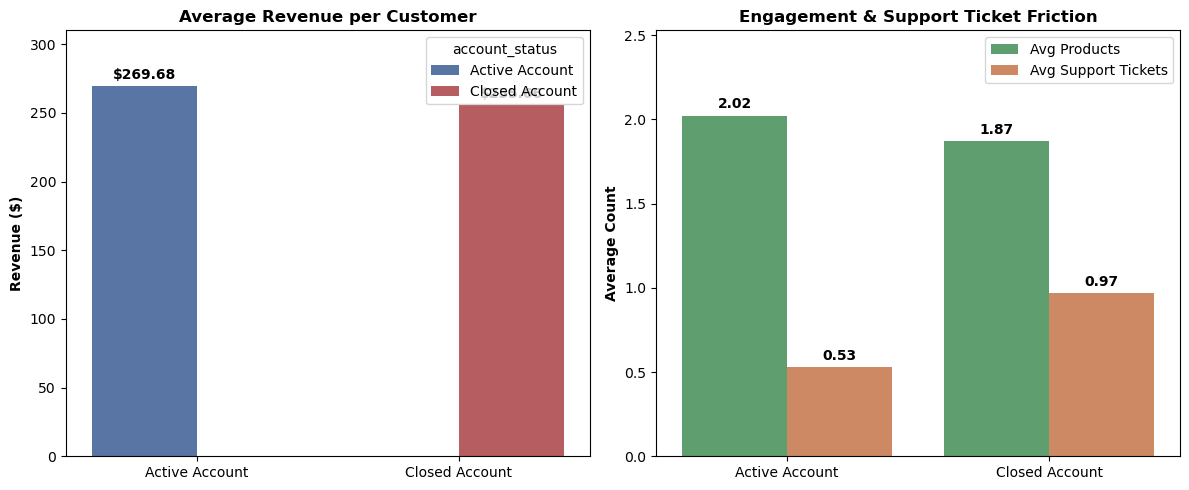

In [9]:
df["account_status"] = df["closed_account"].map(
    {0: "Active Account", 1: "Closed Account"}
)

status_metrics = (
    df.groupby("account_status")
    .agg(
        avg_revenue=("total_revenue", "mean"),
        avg_products=("product_count", "mean"),
        avg_tickets=("support_tickets_ytd", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=status_metrics,
    x="account_status",
    y="avg_revenue",
    ax=axes[0],
    hue="account_status",
    palette=["#4C72B0", "#C44E52"],
)
axes[0].set_title(
    "Average Revenue per Customer", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Revenue ($)", fontweight="bold")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(
        f"${p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )


melted_counts = status_metrics.melt(
    id_vars="account_status",
    value_vars=["avg_products", "avg_tickets"],
    var_name="Metric",
    value_name="Value",
)
melted_counts["Metric"] = melted_counts["Metric"].map(
    {"avg_products": "Avg Products", "avg_tickets": "Avg Support Tickets"}
)

sns.barplot(
    data=melted_counts,
    x="account_status",
    y="Value",
    hue="Metric",
    ax=axes[1],
    palette=["#55A868", "#DD8452"],
)
axes[1].set_title(
    "Engagement & Support Ticket Friction", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Average Count", fontweight="bold")
axes[1].set_xlabel("")
axes[1].legend(title="")
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontweight="bold",
        )

axes[0].set_ylim(0, max(status_metrics["avg_revenue"]) * 1.15)
axes[1].set_ylim(0, max(melted_counts["Value"]) * 1.25)

plt.tight_layout()
plt.show()

## Question B: What appears associated with account closure?

* **Active vs. Closed Volume:** Active accounts represent over 80% of the sample (8x larger than closed accounts), generating **~\$73,000** in total revenue compared to **\$8,000** from closed accounts.

* **Per-Customer Revenue:** Revenue per customer remains virtually identical between the two groups (**\$270** for active vs. **\$256** for closed).

* **Customer Support Driver:** Support ticket volume emerges as a potential churn indicator: closed accounts average nearly double the YTD support tickets of active accounts (**~1.0 vs. 0.5 per customer**). Correlation would require further investigation.

In [10]:
loan_df = df[df["personal_loan_balance"] > 0].copy()

loan_df["is_at_risk"] = loan_df["loan_status"].isin(
    ["30+ Delinquent", "Charged Off"]
)
loan_df["at_risk_balance"] = loan_df["personal_loan_balance"].where(
    loan_df["is_at_risk"], 0
)

In [11]:
def analyze_risk(groupby_col):
    return (
        loan_df.groupby(groupby_col)
        .agg(
            total_customers=("customer_id", "nunique"),
            at_risk_customers=("is_at_risk", "sum"),
            total_loan_balance=("personal_loan_balance", "sum"),
            total_at_risk_balance=("at_risk_balance", "sum"),
        )
        .assign(
            risk_rate=lambda x: (x["at_risk_customers"] / x["total_customers"])
            * 100
        )
        .reset_index()
    )

segment_risk = analyze_risk("customer_segment")
region_risk = analyze_risk("region")
combined_risk = analyze_risk(["customer_segment", "region"])

print("--- RISK BY CUSTOMER SEGMENT ---")
print(segment_risk)
print("\n--- RISK BY REGION ---")
print(region_risk)

--- RISK BY CUSTOMER SEGMENT ---
    customer_segment  total_customers  at_risk_customers  total_loan_balance  \
0           Affluent               10                  1           144109.45   
1  Emerging Affluent               25                  5           302516.17   
2        Mass Market               66                 12          1012773.20   

   total_at_risk_balance  risk_rate  
0               20494.80  10.000000  
1               56719.17  20.000000  
2              198030.91  18.181818  

--- RISK BY REGION ---
      region  total_customers  at_risk_customers  total_loan_balance  \
0    Midwest               25                  3           333739.64   
1  Northeast               32                  3           478993.05   
2      South               25                  8           381902.85   
3       West               19                  4           264763.28   

   total_at_risk_balance  risk_rate  
0               48728.80  12.000000  
1               52260.66   9.3750

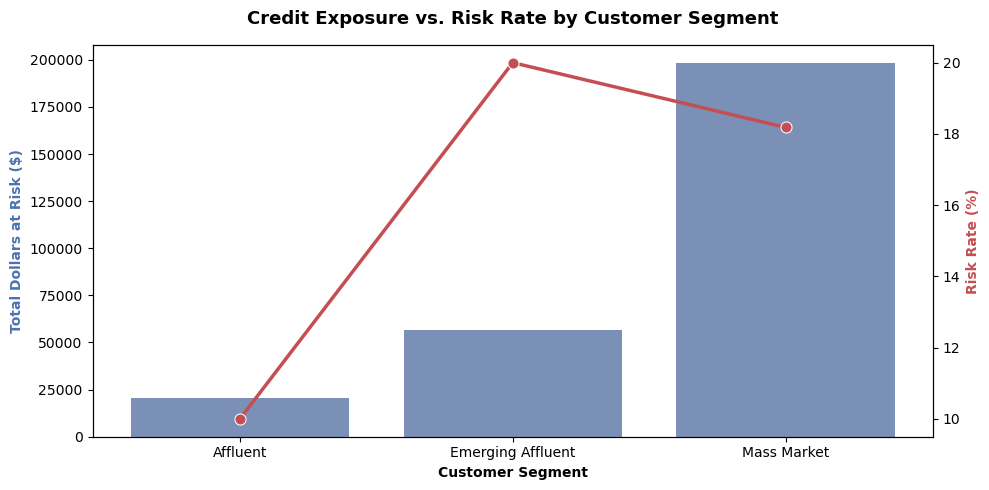

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=segment_risk,
    x="customer_segment",
    y="total_at_risk_balance",
    ax=ax1,
    color="#4C72B0",
    alpha=0.8,
)
ax1.set_ylabel("Total Dollars at Risk ($)", color="#4C72B0", fontweight="bold")
ax1.set_xlabel("Customer Segment", fontweight="bold")

ax2 = ax1.twinx()
sns.lineplot(
    data=segment_risk,
    x="customer_segment",
    y="risk_rate",
    ax=ax2,
    color="#C44E52",
    marker="o",
    linewidth=2.5,
    markersize=8,
)
ax2.set_ylabel("Risk Rate (%)", color="#C44E52", fontweight="bold")
ax2.grid(False)

plt.title(
    "Credit Exposure vs. Risk Rate by Customer Segment",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

## Question C: Where is credit risk concentrated?

By Customer Segment:

* **Most Dollars at Risk:** Mass Market holds the highest capital exposure by far at **$198,031** (driven by high scale with 66 customers). However, its risk rate is **18.18%**.

* **Highest Risk Rate:** Emerging Affluent has the highest credit risk rate at **20.00%** (5 out of 25 customers), despite holding significantly fewer dollars at risk (**\$56,719.17**).

By Region:

* South dominates on both metrics across geographic regions, holding **$115,545** at risk and a **32.00%** risk rate.